# Classificador de Estilo Literário — Portinari

**Objetivo:** classificar se um fragmento de texto foi escrito pelo Cândido Portinari, usando fine-tuning do BERTimbau (`neuralmind/bert-base-portuguese-cased`).

### Correções aplicadas nesta versão
1. **Split por poema** antes de explodir chunks — elimina data leakage entre fragmentos do mesmo poema
2. **Pipeline unificada** — `df_final` removido; treino/teste construídos de forma limpa e única
3. **Split por autor** nos poetas negativos — autores do teste nunca aparecem no treino, impedindo que o modelo aprenda "quem é Drummond" em vez de "o que é estilo Portinari"
4. **GroupKFold (5 folds)** com grupos por poema (Portinari) e por autor (outros) — avaliação robusta com média e desvio padrão entre folds
5. **Épocas reduzidas para 4** com early stopping implícito via `load_best_model_at_end`
6. **Log de truncamentos** — avisa quantos chunks ultrapassaram 128 tokens

In [1]:
import sys
sys.path.insert(0, '..')

caminho_poemas_portinari = '../Data/poemas.csv'
caminho_poemas_extra     = '../Data/portuguese-poems.csv'

## 1. Funções de pré-processamento

In [2]:
import pandas as pd
import re

def limpar_texto(texto):
    """Remove quebras de linha e espaços extras."""
    if not isinstance(texto, str):
        return ""
    texto = re.sub(r'[\n\r\t]+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def fatiar_por_palavras(texto, tamanho_chunk=40, minimo=15):
    """Divide o texto em chunks de `tamanho_chunk` palavras.
    Descarta chunks com menos de `minimo` palavras (final de poema).
    """
    palavras = texto.split()
    chunks = []
    for i in range(0, len(palavras), tamanho_chunk):
        chunk = " ".join(palavras[i:i + tamanho_chunk])
        if len(chunk.split()) >= minimo:
            chunks.append(chunk)
    return chunks

## 2. Carregar e preparar os dados

In [3]:
from sklearn.model_selection import train_test_split

# --- PORTINARI (classe 1) ---
portinari_raw = pd.read_csv(caminho_poemas_portinari)[['id', 'estrofes']].rename(
    columns={'estrofes': 'texto_original'}
)
portinari_raw['texto_limpo'] = portinari_raw['texto_original'].apply(limpar_texto)

# CORREÇÃO 1: split feito POR POEMA, antes de explodir os chunks.
# Isso garante que nenhum poema apareça parcialmente no treino e parcialmente no teste.
ids_treino_port, ids_teste_port = train_test_split(
    portinari_raw['id'].tolist(), test_size=0.2, random_state=42
)

port_treino_raw = portinari_raw[portinari_raw['id'].isin(ids_treino_port)].copy()
port_teste_raw  = portinari_raw[portinari_raw['id'].isin(ids_teste_port)].copy()

# Explodir chunks DEPOIS do split
port_treino_raw['chunks'] = port_treino_raw['texto_limpo'].apply(fatiar_por_palavras)
port_teste_raw['chunks']  = port_teste_raw['texto_limpo'].apply(fatiar_por_palavras)

port_treino = port_treino_raw.explode('chunks').dropna(subset=['chunks'])\
                             .rename(columns={'chunks': 'texto'})[['texto']]
port_teste  = port_teste_raw.explode('chunks').dropna(subset=['chunks'])\
                            .rename(columns={'chunks': 'texto'})[['texto']]

port_treino['label'] = 1
port_teste['label']  = 1

print(f"Portinari — poemas treino: {len(ids_treino_port)} | chunks treino: {len(port_treino)}")
print(f"Portinari — poemas teste:  {len(ids_teste_port)}  | chunks teste:  {len(port_teste)}")

Portinari — poemas treino: 88 | chunks treino: 199
Portinari — poemas teste:  23  | chunks teste:  62


In [4]:
# --- OUTROS POETAS BRASILEIROS (classe 0) ---
autores_brasileiros = [
    'Carlos Drummond de Andrade', 'Vinicius de Moraes', 'Ariano Suassuna',
    'Augusto dos Anjos', 'Paulo Leminski', 'Adélia Prado', 'Castro Alves',
    'Luis Fernando Verissimo', 'Frederico Barbosa', 'Paulo Setúbal',
    'Joaquim Cardozo', 'Sousândrade', 'Pedro Kilkerry', 'Artur de Azevedo',
    'Afonso Schmidt', 'Nauro Machado', 'Silva Alvarenga', 'Murillo Araújo',
    'Marcelo Gama', 'Raquel Naveira', 'Fernando Paixão',
    'Edimilson de Almeida Pereira', 'Cecília Meireles'
]

poemas_extra = pd.read_csv(caminho_poemas_extra)
poemas_br = poemas_extra[poemas_extra['Author'].isin(autores_brasileiros)].copy()
poemas_br['texto_limpo'] = poemas_br['Content'].apply(limpar_texto)

# FIX: split por AUTOR — autores do teste nunca aparecem no treino.
# Isso impede o modelo de aprender "quem é Drummond" em vez de "o que é estilo Portinari".
autores_unicos = poemas_br['Author'].unique().tolist()
autores_treino, autores_teste = train_test_split(
    autores_unicos, test_size=0.2, random_state=42
)

print("Autores no TREINO:", sorted(autores_treino))
print("Autores no TESTE: ", sorted(autores_teste))

def explodir_autor(df):
    df = df.copy()
    df['chunks'] = df['texto_limpo'].apply(fatiar_por_palavras)
    exp = df.explode('chunks').dropna(subset=['chunks'])\
            .rename(columns={'chunks': 'texto'})[['texto', 'Author']]
    exp['label'] = 0
    return exp

poemas_treino_exp = explodir_autor(poemas_br[poemas_br['Author'].isin(autores_treino)])
poemas_teste_exp  = explodir_autor(poemas_br[poemas_br['Author'].isin(autores_teste)])

print(f"\nChunks treino outros: {len(poemas_treino_exp)}")
print(f"Chunks teste outros:  {len(poemas_teste_exp)}")

Autores no TREINO: ['Afonso Schmidt', 'Ariano Suassuna', 'Artur de Azevedo', 'Augusto dos Anjos', 'Carlos Drummond de Andrade', 'Castro Alves', 'Edimilson de Almeida Pereira', 'Fernando Paixão', 'Frederico Barbosa', 'Luis Fernando Verissimo', 'Marcelo Gama', 'Murillo Araújo', 'Nauro Machado', 'Paulo Setúbal', 'Pedro Kilkerry', 'Silva Alvarenga', 'Sousândrade', 'Vinicius de Moraes']
Autores no TESTE:  ['Adélia Prado', 'Cecília Meireles', 'Joaquim Cardozo', 'Paulo Leminski', 'Raquel Naveira']

Chunks treino outros: 3078
Chunks teste outros:  482


In [5]:
# --- BALANCEAR: igualar quantidade de classe 0 e classe 1 em treino e teste ---

# Treino
n_treino = len(port_treino)
outros_treino = poemas_treino_exp.sample(n=n_treino, random_state=42)

treino_df = pd.concat([port_treino, outros_treino])\
              .sample(frac=1, random_state=42)\
              .reset_index(drop=True)

# Teste
n_teste = len(port_teste)
outros_teste = poemas_teste_exp.sample(n=n_teste, random_state=42)

teste_df = pd.concat([port_teste, outros_teste])\
             .sample(frac=1, random_state=42)\
             .reset_index(drop=True)

print(f"Dataset de treino: {len(treino_df)} fragmentos ({n_treino} por classe)")
print(f"Dataset de teste:  {len(teste_df)} fragmentos ({n_teste} por classe)")
print()
print("Distribuição treino:")
print(treino_df['label'].value_counts())
print()
print("Distribuição teste:")
print(teste_df['label'].value_counts())

Dataset de treino: 398 fragmentos (199 por classe)
Dataset de teste:  124 fragmentos (62 por classe)

Distribuição treino:
label
1    199
0    199
Name: count, dtype: int64

Distribuição teste:
label
1    62
0    62
Name: count, dtype: int64


## 3. Verificar GPU

In [6]:
import torch

print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")
print(f"Versão CUDA: {torch.version.cuda}")

CUDA disponível: True
GPU: NVIDIA RTX A4500
Versão CUDA: 12.8


## 4. Tokenização e criação dos datasets HuggingFace

In [7]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from transformers import BertTokenizerFast
from datasets import Dataset

torch.cuda.empty_cache()

MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

MAX_LENGTH = 128

def tokenizar_batch(batch):
    return tokenizer(
        batch['texto'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

dataset_treino = Dataset.from_pandas(treino_df)
dataset_teste  = Dataset.from_pandas(teste_df)

dataset_treino = dataset_treino.map(tokenizar_batch, batched=True)
dataset_teste  = dataset_teste.map(tokenizar_batch, batched=True)

# CORREÇÃO 3: log de truncamentos para detectar perda silenciosa de conteúdo
n_truncados = sum(
    1 for t in treino_df['texto']
    if len(tokenizer.encode(t)) > MAX_LENGTH
)
pct = n_truncados / len(treino_df) * 100
print(f"\nChunks truncados no treino: {n_truncados}/{len(treino_df)} ({pct:.1f}%)")
if pct > 10:
    print("  ⚠️  Mais de 10% truncados — considere aumentar max_length para 256.")
else:
    print("  ✅ Truncamentos dentro do aceitável.")

Usando device: cuda


Map:   0%|          | 0/398 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]


Chunks truncados no treino: 0/398 (0.0%)
  ✅ Truncamentos dentro do aceitável.


## 5. Treinamento

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import GroupKFold
import numpy as np

# GroupKFold garante que:
#   - chunks do mesmo POEMA (Portinari) ficam no mesmo fold
#   - chunks do mesmo AUTOR (outros) ficam no mesmo fold
# Nenhum dos dois vaza entre treino e validação.

N_FOLDS = 5

# Montar dataset completo com grupos definidos
port_all = pd.concat([port_treino, port_teste]).copy()
port_all['group'] = port_all.index.map(
    lambda i: port_treino_raw['id'].iloc[i % len(port_treino_raw)]
    if i < len(port_treino) else port_teste_raw['id'].iloc[(i - len(port_treino)) % len(port_teste_raw)]
)

outros_all = pd.concat([poemas_treino_exp, poemas_teste_exp]).copy()
outros_all['group'] = outros_all['Author']

# Dataset unificado com coluna de grupo
df_full = pd.concat([
    port_all[['texto', 'label', 'group']],
    outros_all[['texto', 'label', 'group']]
]).reset_index(drop=True)

grupos = df_full['group'].values
gkf    = GroupKFold(n_splits=N_FOLDS)

metricas_folds = []

for fold, (idx_treino, idx_val) in enumerate(gkf.split(df_full, df_full['label'], grupos)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}/{N_FOLDS}")

    fold_treino = df_full.iloc[idx_treino][['texto', 'label']].reset_index(drop=True)
    fold_val    = df_full.iloc[idx_val][['texto', 'label']].reset_index(drop=True)

    # Balancear dentro do fold
    n_min = min(fold_treino['label'].value_counts())
    fold_treino = pd.concat([
        fold_treino[fold_treino['label'] == 0].sample(n=n_min, random_state=fold),
        fold_treino[fold_treino['label'] == 1].sample(n=n_min, random_state=fold)
    ]).sample(frac=1, random_state=fold).reset_index(drop=True)

    print(f"Treino: {len(fold_treino)} | Validação: {len(fold_val)}")

    ds_treino = Dataset.from_pandas(fold_treino).map(tokenizar_batch, batched=True)
    ds_val    = Dataset.from_pandas(fold_val).map(tokenizar_batch, batched=True)

    modelo_fold = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True).to(device)

    args_fold = TrainingArguments(
        output_dir=f'./resultados_fold_{fold}',
        eval_strategy='epoch',
        save_strategy='no',           # não salva checkpoints intermediários por fold
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=4,
        weight_decay=0.01,
        load_best_model_at_end=False,
        logging_steps=20,
        report_to='none'
    )

    trainer_fold = Trainer(
        model=modelo_fold,
        args=args_fold,
        train_dataset=ds_treino,
        eval_dataset=ds_val,
    )

    trainer_fold.train()

    preds   = trainer_fold.predict(ds_val)
    y_pred  = np.argmax(preds.predictions, axis=1)
    y_true  = preds.label_ids
    acuracia = (y_pred == y_true).mean()
    metricas_folds.append(acuracia)
    print(f"Acurácia fold {fold + 1}: {acuracia:.2%}")

print(f"\n{'='*50}")
print(f"Acurácia média: {np.mean(metricas_folds):.2%} ± {np.std(metricas_folds):.2%}")
print("Resultado por fold:", [f"{m:.2%}" for m in metricas_folds])


FOLD 1/5
Treino: 522 | Validação: 1718


Map:   0%|          | 0/522 [00:00<?, ? examples/s]

Map:   0%|          | 0/1718 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

...

Map:   0%|          | 0/525 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss
1,0.452866,0.237833
2,0.052865,0.480570
3,0.021109,0.423518
4,0.005249,0.216030


Acurácia fold 5: 93.14%

Acurácia média: 90.91% ± 6.58%
Resultado por fold: ['97.15%', '84.60%', '81.75%', '97.91%', '93.14%']


## 6. Avaliação

--- RELATÓRIO DE AVALIAÇÃO ---
               precision    recall  f1-score   support

Não Portinari       0.98      0.97      0.98        62
    Portinari       0.97      0.98      0.98        62

     accuracy                           0.98       124
    macro avg       0.98      0.98      0.98       124
 weighted avg       0.98      0.98      0.98       124



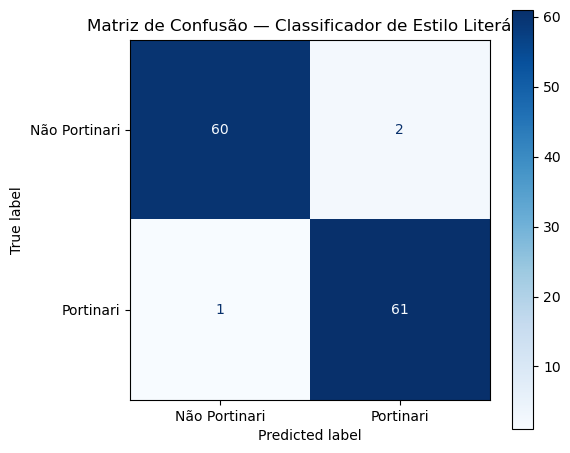

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

preds_output = trainer_fold.predict(dataset_teste)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

nomes_classes = ['Não Portinari', 'Portinari']

print("--- RELATÓRIO DE AVALIAÇÃO ---")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=nomes_classes)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão — Classificador de Estilo Literário')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [10]:
# Salvar resultados detalhados em CSV
resultados_df = teste_df.copy()
resultados_df['predicao'] = y_pred
resultados_df['acerto']   = (y_pred == y_true).astype(int)

mapa_labels = {0: 'Não Portinari', 1: 'Portinari'}
resultados_df['label_nome']    = resultados_df['label'].map(mapa_labels)
resultados_df['predicao_nome'] = resultados_df['predicao'].map(mapa_labels)

resultados_df.to_csv('./resultados_teste.csv', index=False, encoding='utf-8')

print(f"Acurácia geral no teste: {resultados_df['acerto'].mean():.2%}\n")

print("Detalhamento por classe:")
resumo = resultados_df.groupby(['label_nome', 'acerto']).size().unstack(fill_value=0)
resumo.rename(columns={0: 'Erros', 1: 'Acertos'}, inplace=True)
print(resumo.to_string())

Acurácia geral no teste: 97.58%

Detalhamento por classe:
acerto         Erros  Acertos
label_nome                   
Não Portinari      2       60
Portinari          1       61


In [11]:
# Inspecionar os erros do modelo
df_resultados = pd.read_csv('./resultados_teste.csv')
erros_df = df_resultados[df_resultados['acerto'] == 0]

print(f"Total de erros: {len(erros_df)}\n")
for _, row in erros_df.iterrows():
    print(f"Texto:    {row['texto']}")
    print(f"Gabarito: {row['label_nome']}")
    print(f"Previsão: {row['predicao_nome']}")
    print("=" * 60)

Total de erros: 3

Texto:    sua grande arcada O vento soprando teus poemas. E a noite silenciosa será sempre tua Emily Emily
Gabarito: Portinari
Previsão: Não Portinari
Texto:    Salinas de Santo Amaro,Ondas de terra salgada,Revoltas, na escuridão,De silêncio e de naufrágioCobrindo a tantos no chão.Terra crescida, plantadaDe muita recordação.
Gabarito: Não Portinari
Previsão: Portinari
Texto:    um rio profundo. Por fim, os peixes na travessa, vamos dormir. Coisas prateadas espocam: somos noivo e noiva.
Gabarito: Não Portinari
Previsão: Portinari
